In [1]:
from obspy import *
import pandas as pd
import matplotlib.pyplot as plt
from obspy.clients.fdsn import Client
import matplotlib.dates as mdates
import numpy as np

/Users/kitsellusted/miniconda3/envs/pygmt-env/lib/python3.11/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)
/Users/kitsellusted/grad_school/VANDA_work/vnda_picker_orig.py:50: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client2.get_waveforms(


No earthquakes for this time period.


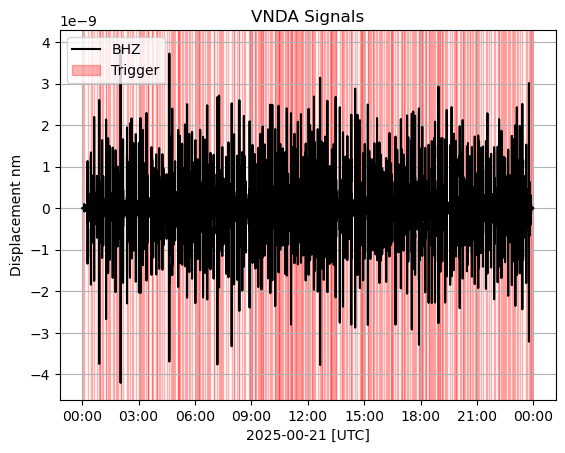

In [8]:
#Call vnda_picker_orig.py with the associated date range. This will output a list of trigger times. 
#I have the plottnig function of this set to False. Change to true to see the waveform/spectrogram
%run vnda_picker_orig.py 2025-11-21T00:00:00 2025-11-28T00:00:00


In [47]:

st_hr.stats

               network: GT
               station: VNDA
              location: 00
               channel: BHZ
             starttime: 2025-11-21T02:59:45.000000Z
               endtime: 2025-11-21T03:59:45.000000Z
         sampling_rate: 40.0
                 delta: 0.025
                  npts: 144001
                 calib: 1.0
_fdsnws_dataselect_url: https://service.earthscope.org/fdsnws/dataselect/1/query
               _format: MSEED
                 mseed: AttribDict({'dataquality': 'M', 'number_of_records': 6665, 'encoding': 'STEIM2', 'byteorder': '>', 'record_length': 512, 'filesize': 1048576})
            processing: ['ObsPy 1.5.0: trim(endtime=UTCDateTime(2025, 11, 22, 0, 0)::fill_value=None::nearest_sample=True::pad=False::starttime=UTCDateTime(2025, 11, 21, 0, 0))', "ObsPy 1.5.0: remove_response(fig=None::inventory=None::output='DISP'::plot=False::pre_filt=[0.001, 0.005, 18.0, 20.0]::taper=True::taper_fraction=0.05::water_level=60::zero_mean=True)", "ObsPy 1.5.0: detrend(o

In [63]:
if t[1]<end:
    print('yes')
else:
    print('no')

no


In [71]:
end

2025-11-21T03:00:00.000000Z

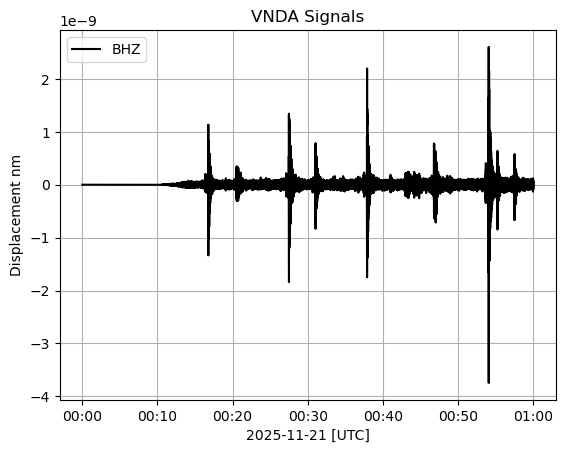

In [78]:
#this is an optional plotting by hour chunks section to make sure the picker is still doing what it should.
#Don't quite have it working yet. Can't get it to loop over the start to end date and plot the triggers at the same length....

fig, ax = plt.subplots(1)
# Plot the waveform
start = st[0].stats.starttime
end = start+(3600*3)
st[0].taper(0.01)

while start<end:
    hour_chunk = start+3600
    st_hr = st[0].slice(start,hour_chunk)
    #Plot signal
    ax.plot(st_hr.times("matplotlib"), st_hr.data, "k-", label = st[0].stats.channel)
    start = hour_chunk
    # Plot the triggers
    #k = 0
    #for t in trig_times:
        #if t[1]<end:
           # t1 = mdates.date2num(t[0].datetime)
           # t2 = mdates.date2num(t[1].datetime)
           # if k == 0:
           #     ax.axvspan(t1, t2, color="red", alpha=0.3, label="Trigger")
          #  else:
           #     ax.axvspan(t1, t2, color="red", alpha=0.3)
       # k = k + 1
    
    # Labels and such
    ax.set_ylabel('Displacement nm')
    ax.set_xlabel('%s [UTC]' % st_hr.stats.starttime.strftime('%Y-%m-%d'))
    
    ax.legend()
    tfmt = mdates.DateFormatter('%H:%M')
    ax.xaxis.set_major_formatter(tfmt)
    ax.xaxis_date()
   
    # Turn on a grids
    ax.grid(True, 'both')     
    
    # Title
    ax.title.set_text('VNDA Signals')
   
    plt.show()
    
    


In [3]:
#Trigger dataframe stuff
trigger_df = pd.DataFrame(trig_times)

#trigger_df.set_index()
trigger_df[0] = [t.datetime for t in trigger_df[0]]
trigger_df[1] = [t.datetime for t in trigger_df[1]]
trigger_df['month'] = trigger_df[0].dt.month
trigger_df['day'] = trigger_df[0].dt.day
trigger_df['hour_UTC'] = trigger_df[0].dt.hour

#Times in local Antarctica time, better for daylight tracking, diurnal patterns
trigger_df['local'] = trigger_df[0].dt.tz_localize('UTC').dt.tz_convert('Antarctica/McMurdo')
trigger_df['hour_local'] = trigger_df['local'].dt.hour
trigger_df['day_local'] = trigger_df['local'].dt.day
trigger_df.rename(columns={0:'onset', 1:'offset'}, inplace = True)


#Hourly and Daily counts
hourly_counts = trigger_df.groupby(pd.Grouper(key='local', freq='h')).size() #in local time
daily_counts = trigger_df.groupby(pd.Grouper(key='local', freq='D')).size() # in local time

trigger_df

,onset,offset,month,day,hour_UTC,local,hour_local,day_local
0,2025-11-21 00:01:35.300,2025-11-21 00:01:36.975,11,21,0,2025-11-21 13:01:35.300000+13:00,13,21
1,2025-11-21 00:05:55.250,2025-11-21 00:05:56.750,11,21,0,2025-11-21 13:05:55.250000+13:00,13,21
2,2025-11-21 00:16:45.600,2025-11-21 00:16:46.600,11,21,0,2025-11-21 13:16:45.600000+13:00,13,21
3,2025-11-21 00:27:29.025,2025-11-21 00:27:30.525,11,21,0,2025-11-21 13:27:29.025000+13:00,13,21
4,2025-11-21 00:31:01.250,2025-11-21 00:31:02.725,11,21,0,2025-11-21 13:31:01.250000+13:00,13,21
...,...,...,...,...,...,...,...,...
336,2025-11-21 23:46:18.425,2025-11-21 23:46:20.400,11,21,23,2025-11-22 12:46:18.425000+13:00,12,22
337,2025-11-21 23:48:55.300,2025-11-21 23:48:57.725,11,21,23,2025-11-22 12:48:55.300000+13:00,12,22
338,2025-11-21 23:52:33.125,2025-11-21 23:52:34.800,11,21,23,2025-11-22 12:52:33.125000+13:00,12,22
339,2025-11-21 23:53:56.925,2025-11-21 23:53:58.325,11,21,23,2025-11-22 12:53:56.925000+13:00,12,22


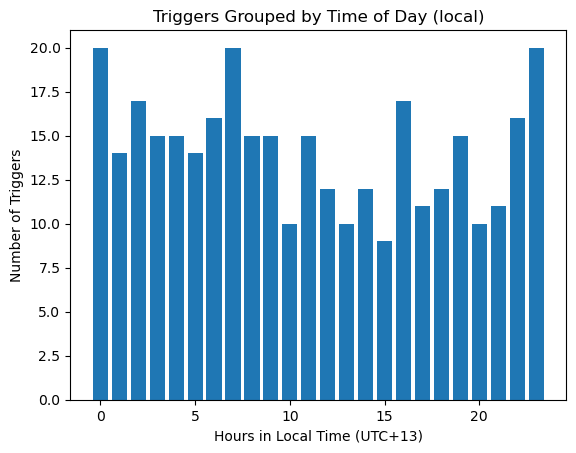

In [5]:
#Plot daily occurances
 
fig, ax = plt.subplots()
ax.bar(trigger_df['hour_local'].unique(), hourly_counts) #local time
ax.set_xlabel('Hours in Local Time (UTC+13)')
ax.set_ylabel('Number of Triggers')
ax.set_title('Triggers Grouped by Time of Day (local)')
plt.show()


In [6]:
trigger_df['local'].dt.date.unique()

array([datetime.date(2025, 11, 21), datetime.date(2025, 11, 22)],
      dtype=object)

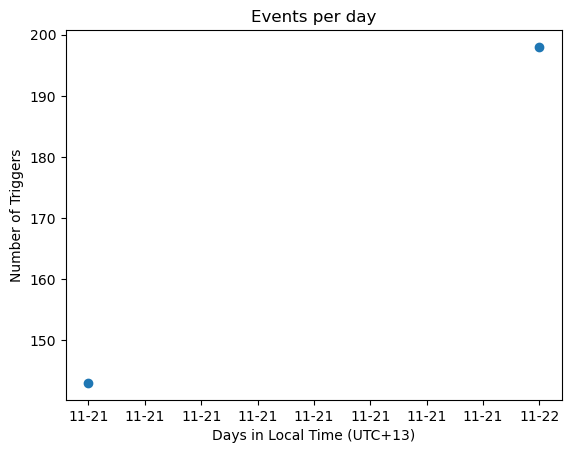

In [7]:
fig, ax = plt.subplots()
ax.scatter(pd.to_datetime(trigger_df['local'].dt.date.unique()), daily_counts)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.set_xlabel('Days in Local Time (UTC+13)')
ax.set_title("Events per day")
ax.set_ylabel('Number of Triggers')
plt.show()